# Benchmark Notebook: 5 Open-Source VLMs for StreetPLM Scene Understanding

Benchmarks 5 open-source VLMs on the **StreetPLM scene understanding task** — the same
zone-based semantic analysis used in `02_run_vlm_analysis.py`. Each model receives the
identical `SYSTEM_PROMPT` + `USER_PROMPT` and produces output validated by `StreetSceneAnalysis`.

**Hardware:** NVIDIA L4 (24 GB GDDR6, Ada Lovelace sm_89) · Flash Attention 2 · bfloat16

**Models:** Qwen3-VL-8B · LLaVA-OneVision-7B · InternVL2.5-8B · Phi-3.5-Vision · Idefics3-8B

**Output:** `vlm_analysis_outputs/{slug}_analysis.json` — one per model, same format as production pipeline.

> Models loaded and deleted sequentially to stay within 24 GB VRAM. Total download ~70-80 GB.

In [ ]:
# transformers pinned to >=4.49 for Qwen3VLForConditionalGeneration
!pip install -q "transformers>=4.49.0" accelerate timm pillow numpy qwen-vl-utils einops torchvision python-dotenv huggingface_hub pydantic sentencepiece

import subprocess as _sp, sys as _sys
_nvcc = _sp.run(['nvcc', '--version'], capture_output=True)
if _nvcc.returncode == 0:
    _sp.run([_sys.executable, '-m', 'pip', 'install', 'flash-attn', '--no-cache-dir', '--no-build-isolation', '-q'])
else:
    print('nvcc not found - skipping flash-attn')

import subprocess
result = subprocess.run(['pip', 'show', 'transformers'], capture_output=True, text=True)
for line in result.stdout.splitlines():
    if line.startswith('Version'):
        print(f'transformers {line}')
        break

In [2]:
import json, re, math, time
import numpy as np
import torch
from PIL import Image
from datetime import datetime, timezone
from pathlib import Path

print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

import transformers
print(f'Transformers: {transformers.__version__}')

FLASH_ATTN = False
try:
    import flash_attn
    from transformers.utils import is_flash_attn_2_available
    FLASH_ATTN = is_flash_attn_2_available()
    print(f'Flash Attention: {"available" if FLASH_ATTN else "not usable"}')
except Exception:
    print('Flash Attention: not available')

ATTN = 'flash_attention_2' if FLASH_ATTN else 'eager'

def _load_with_attn_fallback(load_fn, *args, **kwargs):
    try:
        return load_fn(*args, attn_implementation=ATTN, **kwargs)
    except (KeyError, ValueError, ImportError, RuntimeError):
        print('  flash_attention_2 failed - retrying with eager')
        return load_fn(*args, attn_implementation='eager', **kwargs)

def _free_vram_gib():
    free_bytes, _ = torch.cuda.mem_get_info()
    return max(int(free_bytes / (1024**3)) - 1, 1)

PyTorch: 2.8.0+cu128
CUDA: True
GPU: NVIDIA L4
Transformers: 4.49.0
Flash Attention: available


In [3]:
import os
from dotenv import load_dotenv
import huggingface_hub

for candidate in [
    Path.cwd() / '.env',
    Path.cwd().parent / '.env',
    Path('/teamspace/studios/this_studio/LLM_Based_UrbanABM/.env'),
]:
    if candidate.exists():
        load_dotenv(candidate, override=False)
        print(f'Loaded .env from: {candidate}')
        break

hf_token = os.getenv('HF_TOKEN')
if hf_token:
    huggingface_hub.login(token=hf_token, add_to_git_credential=False)
    print('Logged in to HuggingFace Hub')
else:
    print('HF_TOKEN not set')

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loaded .env from: /teamspace/studios/this_studio/.env
Logged in to HuggingFace Hub


In [4]:
import shutil

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    vram_gb = props.total_memory / 1e9
    print(f'GPU  : {props.name}')
    print(f'VRAM : {vram_gb:.1f} GB')
    print(f'Arch : sm_{props.major}{props.minor}')
else:
    print('WARNING: No CUDA device')

total, used, free = shutil.disk_usage('/')
print(f'Disk : {free/1e9:.1f} GB free of {total/1e9:.1f} GB')
if free / 1e9 < 80:
    print('WARNING: Less than 80 GB free')

GPU  : NVIDIA L4
VRAM : 23.7 GB
Arch : sm_89
Disk : 433.7 GB free of 589.4 GB


Status  : OK
Date    : 2024-08
Image: (640, 618)


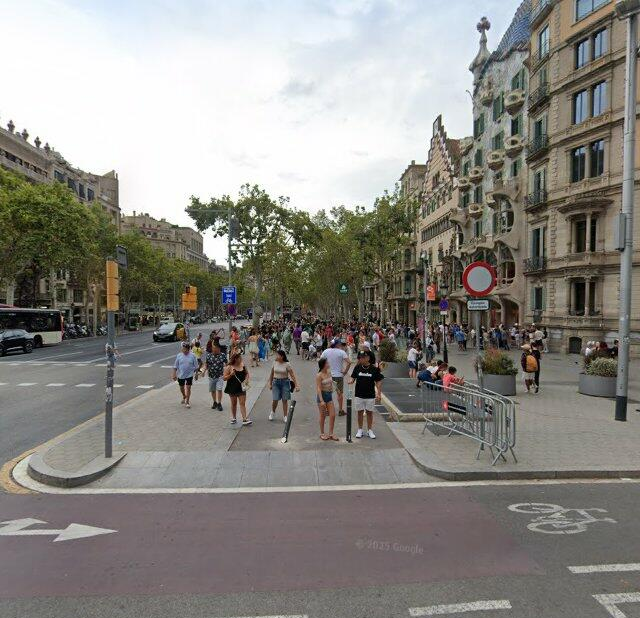

In [5]:
import requests
from io import BytesIO

api_key = os.getenv('GOOGLE_STREETVIEW_API_KEY')
if not api_key:
    raise EnvironmentError('GOOGLE_STREETVIEW_API_KEY not found.')

SV_PARAMS = {
    'size':    '640x640',
    'pano':    'xEkwlZmPGMjERyF53oJ3rA',
    'heading': '139',
    'pitch':   '-2',
    'fov':     '75',
    'key':     api_key,
}

BASE = 'https://maps.googleapis.com/maps/api/streetview'
meta = requests.get(f'{BASE}/metadata', params=SV_PARAMS, timeout=15).json()
print(f'Status  : {meta.get("status")}')
print(f'Date    : {meta.get("date", "unknown")}')

if meta.get('status') == 'OK':
    response = requests.get(BASE, params=SV_PARAMS, timeout=30)
    response.raise_for_status()
    img = Image.open(BytesIO(response.content)).convert('RGB')
    img = img.crop((0, 0, img.width, img.height - 22))  # crop watermark
    IMAGE_PATH = 'barcelona_streetview.jpg'
    img.save(IMAGE_PATH)
    print(f'Image: {img.size}')
    display(img)
else:
    # Use existing local file if available
    IMAGE_PATH = 'barcelona_streetview.jpg'
    if not Path(IMAGE_PATH).exists():
        raise RuntimeError('Street View unavailable and no local image found.')
    print(f'Using existing local image: {IMAGE_PATH}')

In [ ]:
from pydantic import BaseModel, Field, field_validator
from typing import List, Literal, Optional
import re

# Flat-array schema: each category is a sparse list; only observed zones appear.
_ZONE = Literal["far_left", "left", "center", "right", "far_right"]
_ZONES = ("far_left", "left", "center", "right", "far_right")

class LightingEntry(BaseModel):
    zone: _ZONE = "center"
    element: str = ""
    condition: Literal["dark", "dim", "adequate", "bright", "unknown"] = "adequate"

class SpatialCharacterEntry(BaseModel):
    zone: _ZONE = "center"
    width: Literal["narrow", "moderate", "wide", "unknown"] = "unknown"
    enclosure: Literal["open", "semi", "enclosed", "unknown"] = "unknown"
    passability: Literal["clear", "caution", "obstructed", "blocked"] = "clear"
    lane_type: Literal["sidewalk", "main_roadway", "shared_bus_lane", "bicycle_lane", "median", "shared", "road", "unknown"] = "unknown"
    crossing: Literal["none", "zebra", "signalised", "unknown"] = "none"
    architectural_style: Literal["neo_gothic", "modernist", "contemporary", "neoclassical", "vernacular", "eclectic", "art_deco", "art_nouveau", "other", "unknown"] = "unknown"
    building_condition: Literal["excellent", "good", "fair", "poor", "under_construction", "unknown"] = "unknown"
    storefront_type: Literal["retail", "restaurant", "cafe", "office", "residential", "hotel", "vacant", "cultural", "industrial", "other", "unknown"] = "unknown"
    architectural_details: Optional[str] = None

class CrowdednessEntry(BaseModel):
    zone: _ZONE = "center"
    density_level: Literal["empty", "sparse", "moderate", "dense", "unknown"] = "empty"

class GreeneryEntry(BaseModel):
    zone: _ZONE = "center"
    element: str = ""
    coverage: Literal["none", "sparse", "moderate", "dense", "unknown"] = "none"

class StreetAmenityEntry(BaseModel):
    zone: _ZONE = "center"
    element: str = ""
    material_and_colour: str = ""
    presence: Literal["none", "few", "several", "many", "unknown"] = "unknown"

class VisibleTextEntry(BaseModel):
    text: str = ""
    zone: _ZONE = "center"
    type: Literal["sign", "signage", "board", "banner", "label", "graffiti", "information"] = "sign"

class StreetSceneAnalysis(BaseModel):
    scene: str = "unknown"
    lighting:          List[LightingEntry]         = Field(default_factory=list)
    spatial_character: List[SpatialCharacterEntry] = Field(default_factory=list)
    crowdedness:       List[CrowdednessEntry]       = Field(default_factory=list)
    greenery:          List[GreeneryEntry]          = Field(default_factory=list)
    street_amenities:  List[StreetAmenityEntry]     = Field(default_factory=list)
    visible_text:      List[VisibleTextEntry]        = Field(default_factory=list)

    @field_validator('scene', mode='before')
    @classmethod
    def _coerce_scene(cls, v):
        return str(v).strip() if v else 'unknown'

    @field_validator(
        'lighting', 'spatial_character', 'crowdedness', 'greenery',
        'street_amenities', 'visible_text', mode='before',
    )
    @classmethod
    def _coerce_to_list(cls, v):
        if isinstance(v, list): return v
        if isinstance(v, dict): return [v]
        return []

# Alias so cell-9 error-fallback still works without modification
RestructuredStreetSceneAnalysis = StreetSceneAnalysis

# ── Prompts ───────────────────────────────────────────────────────────────────
SYSTEM_PROMPT = (
    "You are an expert urban perception analyst. Study this street-view image carefully.\n"
    "This scene is located on Passeig de Gracia, Barcelona — a street famous for "
    "Modernisme (Catalan Art Nouveau) architecture by Antoni Gaudí and his contemporaries.\n"
    "Zones left-to-right: far_left | left | center | right | far_right"
)

USER_PROMPT = (
    "Output a JSON object with these 7 fields:\n"
    "  lighting          - [{zone, element: describe the specific light source, condition: dark|dim|adequate|bright}]\n"
    "  spatial_character - [{zone, width: narrow|moderate|wide, enclosure: open|semi|enclosed,\n"
    "                         passability: clear|caution|obstructed|blocked,\n"
    "                         lane_type: sidewalk|main_roadway|shared_bus_lane|bicycle_lane|median|shared|road|unknown,\n"
    "                         crossing: none|zebra|signalised,\n"
    "                         architectural_style: neo_gothic|modernist|contemporary|neoclassical|vernacular|eclectic|art_deco|art_nouveau|other|unknown,\n"
    "                         building_condition: excellent|good|fair|poor|unknown,\n"
    "                         storefront_type: retail|restaurant|cafe|office|residential|hotel|vacant|cultural|other|unknown,\n"
    "                         architectural_details: optional descriptive phrase or null}]\n"
    "  crowdedness       - [{zone, density_level: empty|sparse|moderate|dense}]\n"
    "  greenery          - [{zone, element: specific plant/tree type and description, coverage: none|sparse|moderate|dense}]\n"
    "  street_amenities  - [{zone, element: specific object type, material_and_colour: material and colour, presence: none|few|several|many}]\n"
    "  visible_text      - [{text: exact readable string, zone, type: sign|label|graffiti|board|banner|information}]\n"
    "  scene             - one-sentence overview of this specific street\n\n"
    "Rules:\n"
    "  * Report spatial_character entries for ALL 5 zones (far_left, left, center, right, far_right). Even if a zone has limited visibility, note what you *can* determine (width, lane_type, architectural_style).\n  * For other fields (lighting, crowdedness, greenery, street_amenities), cover only clearly visible zones — 1-3 entries per field, only zones with something notable — 1-3 entries per field, only zones with something notable\n"
    "  * Multiple distinct elements in the same zone = multiple list entries\n"
    "  * element fields: name material, colour, style, scale (e.g. 'grey cast-iron double-arm lamp post')\n"
    "  * visible_text: upper 90% of frame only; skip watermarks, licence plates, blurred text\n"
    "  * Output only the JSON object — no prose, no markdown\n\n"
    "Example (DIFFERENT image — for schema format only, do not copy values):\n"
    '{"lighting":[{"zone":"left","element":"dappled shade from dense tree canopy","condition":"dim"},'
    '{"zone":"center","element":"direct overhead midday sun","condition":"bright"}],'
    '"spatial_character":[{"zone":"left","width":"narrow","enclosure":"enclosed","passability":"clear",'
    '"lane_type":"sidewalk","crossing":"none","architectural_style":"modernist","building_condition":"good",'
    '"storefront_type":"retail","architectural_details":"ornate balconies with wrought-iron railings"},'
    '{"zone":"center","width":"moderate","enclosure":"semi","passability":"clear","lane_type":"road",'
    '"crossing":"zebra","architectural_style":"contemporary","building_condition":"fair",'
    '"storefront_type":"restaurant","architectural_details":null}],'
    '"crowdedness":[{"zone":"left","density_level":"sparse"},{"zone":"center","density_level":"moderate"}],'
    '"greenery":[{"zone":"left","element":"mature London plane trees with mottled grey-green bark","coverage":"dense"},'
    '{"zone":"right","element":"terracotta-potted rosemary shrubs on window ledges","coverage":"sparse"}],'
    '"street_amenities":[{"zone":"left","element":"ornate cast-iron double-arm street lamp with frosted globe",'
    '"material_and_colour":"black painted cast iron","presence":"few"},'
    '{"zone":"center","element":"yellow painted concrete bollard","material_and_colour":"yellow concrete","presence":"several"}],'
    '"visible_text":[{"text":"MERCAT","zone":"far_left","type":"sign"}],'
    '"scene":"Tree-lined residential street with moderate pedestrian activity and parked vehicles."}\n\n'
    "Now analyse THIS image. Output only JSON:"
)

FULL_PROMPT = SYSTEM_PROMPT + '\n\n' + USER_PROMPT

MAX_NEW_TOKENS = 1600
TEMPERATURE    = 0.3
TOP_P          = 0.95
REP_PENALTY    = 1.1
MIN_FIELDS_OK  = 3
MAX_RETRIES    = 4

# ── Helpers ───────────────────────────────────────────────────────────────────
_GOOGLE_WATERMARK_RE = re.compile(r"^(©\s*)?(20\d{2}\s+)?google(\s+maps)?[\s.,]*$", re.IGNORECASE)
_LICENSE_PLATE_RE    = re.compile(r"^[A-Z]{1,4}[\s·\-]?\d{2,4}[\s·\-]?[A-Z]{0,3}$|^\d{4}[\s·\-][A-Z]{2,3}$", re.IGNORECASE)

def _filter_visible_text(entries):
    seen, deduped = set(), []
    for e in entries:
        if not isinstance(e, dict) or not e.get('text'): continue
        txt = e['text']
        if txt in seen or _GOOGLE_WATERMARK_RE.match(txt) or _LICENSE_PLATE_RE.match(txt): continue
        seen.add(txt); deduped.append(e)
    return deduped

_KEY_ALIASES: dict = {
    "scene": "scene", "scene_description": "scene", "overview": "scene", "summary": "scene",
    "lighting": "lighting", "light": "lighting", "light_quality": "lighting",
    "spatial_character": "spatial_character", "spatial": "spatial_character",
    "space": "spatial_character", "street_space": "spatial_character",
    "crowdedness": "crowdedness", "crowding": "crowdedness", "crowd": "crowdedness",
    "pedestrians": "crowdedness", "people": "crowdedness",
    "greenery": "greenery", "vegetation": "greenery", "plants": "greenery", "trees": "greenery",
    "street_amenities": "street_amenities", "amenities": "street_amenities",
    "furniture": "street_amenities", "street_furniture": "street_amenities",
    "visible_text": "visible_text", "text": "visible_text", "signs": "visible_text",
    "ocr": "visible_text", "signage": "visible_text",
}

_ECHO_SENTINELS = frozenset({
    "dark|dim|adequate|bright", "empty|sparse|moderate|dense", "narrow|moderate|wide",
    "clear|caution|obstructed|blocked", "none|zebra|signalised",
    "sidewalk|main_roadway|shared_bus_lane|bicycle_lane|median|shared|road|unknown",
    "neo_gothic|modernist|contemporary|neoclassical|vernacular|eclectic|art_deco|art_nouveau|other|unknown",
    "excellent|good|fair|poor|unknown",
    "retail|restaurant|cafe|office|residential|hotel|vacant|cultural|other|unknown",
    "far_left|left|center|right|far_right",
    "sky|buildings|lamps|trees|...", "trees|shrubs|grass|planters|...",
    "bench|lamp|sign|bin|bollard|...", "sign|label|graffiti|board|banner|information",
    "exact readable string", "exact text you can read",
    "<one-sentence overall description>", "<optional phrase or null>",
    "optional descriptive phrase or null", "metal grey|...",
})

def _model_echoed_template(parsed: dict) -> bool:
    def _has(obj) -> bool:
        if isinstance(obj, str): return obj.strip().lower() in _ECHO_SENTINELS
        if isinstance(obj, dict): return any(_has(v) for v in obj.values())
        if isinstance(obj, list): return any(_has(i) for i in obj)
        return False
    return any(_has(v) for v in parsed.values())

def _parse_json(raw: str):
    raw = raw.replace('```json', '').replace('```', '').strip()
    for _ in range(8):
        raw = raw.replace(',}', '}').replace(',]', ']').replace(', }', '}').replace(', ]', ']')
    try:
        return json.loads(raw)
    except Exception:
        pass
    start = raw.find('{')
    if start >= 0:
        depth = 0
        for i, c in enumerate(raw[start:], start):
            if c == '{': depth += 1
            elif c == '}':
                depth -= 1
                if depth == 0:
                    try: return json.loads(raw[start:i + 1])
                    except Exception: break
    for n in range(1, 8):
        try: return json.loads(raw + ']}' * n)
        except Exception: pass
    result = {}
    for key in ('scene', 'lighting', 'spatial_character', 'crowdedness', 'greenery', 'street_amenities', 'visible_text'):
        m = re.search(rf'"{key}"\s*:\s*(".*?"|[\[{{].*?[\]}}])', raw, re.DOTALL)
        if m:
            try: result[key] = json.loads(m.group(1))
            except Exception: result[key] = m.group(1)
    return result or None

def _normalise_result(raw: dict) -> dict:
    normalised: dict = {}
    for k, v in raw.items():
        canonical = _KEY_ALIASES.get(k.strip().lower())
        if canonical:
            normalised[canonical] = v
    if 'visible_text' in normalised and isinstance(normalised['visible_text'], list):
        normalised['visible_text'] = _filter_visible_text(normalised['visible_text'])
    # Repetition guard: if 3+ spatial entries have identical architectural_style + details, flag them
    if 'spatial_character' in normalised and isinstance(normalised['spatial_character'], list):
        styles_seen = {}
        for entry in normalised['spatial_character']:
            if isinstance(entry, dict):
                sig = (entry.get('architectural_style'), entry.get('architectural_details'))
                styles_seen.setdefault(sig, []).append(entry)
        for sig, entries in styles_seen.items():
            if sig[0] and sig[0] != 'unknown' and len(entries) >= 3:
                zone_list = ', '.join(e.get('zone', '?') for e in entries)
                print(f'  WARNING: suspicious repetition of architectural_style={sig[0]} across zones: {zone_list}')
    try:
        return StreetSceneAnalysis(**normalised).model_dump()
    except Exception:
        return StreetSceneAnalysis().model_dump()

def _parse_scene(text: str) -> dict:
    d = _parse_json(text)
    if not d: return StreetSceneAnalysis().model_dump()
    if _model_echoed_template(d): return StreetSceneAnalysis().model_dump()
    return _normalise_result(d)

def _count_populated(result: dict) -> int:
    score = 0
    if result.get('scene', 'unknown') not in ('unknown', ''):
        score += 1
    for entry in result.get('spatial_character', []):
        if isinstance(entry, dict) and entry.get('lane_type', 'unknown') != 'unknown':
            score += 1
    return score

print('Schema + prompts loaded.')
print(f'MAX_NEW_TOKENS={MAX_NEW_TOKENS}  TEMPERATURE={TEMPERATURE}')



In [7]:
OUT_DIR = Path('vlm_analysis_outputs')
OUT_DIR.mkdir(exist_ok=True)

IMAGE_METADATA = {
    'latitude':          41.391694,
    'longitude':         2.164944,
    'heading':           139.0,
    'street_name':       'Passeig de Gracia',
    'highway_type':      'primary',
    'edge_id':           'benchmark',
    'dist_along_edge_m': None,
    'source_image':      'barcelona_streetview.jpg',
}

def save_result(model_id: str, slug: str, scene_analysis: dict, latency_ms: float, device: str):
    output = {
        'metadata': {
            'timestamp': datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S'),
            **IMAGE_METADATA,
            'model':      model_id,
            'device':     device,
            'latency_ms': latency_ms,
            'status':     'ok',
        },
        'scene_analysis':   scene_analysis,
        'nearby_landmarks': [],
    }
    path = OUT_DIR / f'{slug}_analysis.json'
    path.write_text(json.dumps(output, indent=2, ensure_ascii=False), encoding='utf-8')
    print(f'Saved -> {path}')
    return output

print(f'Output dir: {OUT_DIR.resolve()}')

Output dir: /teamspace/studios/this_studio/vlm_analysis_outputs


In [ ]:
MODEL_REGISTRY = {
    'Qwen/Qwen3-VL-8B-Instruct':              ('Qwen3 VL 8B',        'qwen3vl_8b'),
    'llava-hf/llava-onevision-qwen2-7b-ov-hf': ('LLaVA-OneVision 7B', 'llava_onevision_7b'),
    'OpenGVLab/InternVL2_5-8B':                ('InternVL2.5 8B',      'internvl25_8b'),
    'microsoft/Phi-3.5-vision-instruct':       ('Phi-3.5 Vision',      'phi35_vision'),
    'HuggingFaceM4/Idefics3-8B-Llama3':        ('Idefics3 8B',         'idefics3_8b'),
}

# ── Qwen3-VL (unified apply_chat_template API) ────────────────────────────────
def infer_qwen3vl(model_id):
    from transformers import Qwen3VLForConditionalGeneration, AutoProcessor

    model = _load_with_attn_fallback(
        Qwen3VLForConditionalGeneration.from_pretrained,
        model_id, torch_dtype=torch.bfloat16, device_map='auto'
    )
    processor = AutoProcessor.from_pretrained(model_id)

    image = Image.open(IMAGE_PATH)
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': [
            {'type': 'image', 'image': image},
            {'type': 'text',  'text': USER_PROMPT},
        ]},
    ]
    inputs = processor.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_dict=True, return_tensors='pt',
    ).to('cuda')

    t0 = time.perf_counter()
    with torch.no_grad():
        ids = model.generate(
            **inputs, max_new_tokens=MAX_NEW_TOKENS,
            do_sample=True, temperature=0.7, top_p=0.8, top_k=20,
            repetition_penalty=REP_PENALTY,
        )
    latency_ms = (time.perf_counter() - t0) * 1000
    output = processor.batch_decode(
        [o[len(i):] for i, o in zip(inputs.input_ids, ids)],
        skip_special_tokens=True
    )[0]
    del model, processor; torch.cuda.empty_cache()
    return output, latency_ms

# ── LLaVA-OneVision (user-only, FULL_PROMPT) ──────────────────────────────────
def infer_llava_onevision_7b(model_id):
    import warnings
    from transformers import LlavaOnevisionForConditionalGeneration, AutoProcessor

    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', message='.*device_map keys do not match.*')
        model = _load_with_attn_fallback(
            LlavaOnevisionForConditionalGeneration.from_pretrained,
            model_id, torch_dtype=torch.bfloat16, device_map='auto',
            low_cpu_mem_usage=True,
            max_memory={0: f'{_free_vram_gib()}GiB', 'cpu': '30GiB'},
        )
    processor = AutoProcessor.from_pretrained(model_id)

    image = Image.open(IMAGE_PATH)
    conversation = [{'role': 'user', 'content': [
        {'type': 'image'}, {'type': 'text', 'text': FULL_PROMPT}
    ]}]
    prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)
    inputs = processor(images=image, text=prompt, return_tensors='pt').to('cuda')

    t0 = time.perf_counter()
    with torch.no_grad():
        ids = model.generate(
            **inputs, max_new_tokens=MAX_NEW_TOKENS,
            do_sample=True, temperature=TEMPERATURE, top_p=TOP_P,
            repetition_penalty=REP_PENALTY,
            pad_token_id=processor.tokenizer.eos_token_id,
        )
    latency_ms = (time.perf_counter() - t0) * 1000
    output = processor.decode(ids[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    del model, processor; torch.cuda.empty_cache()
    return output, latency_ms

# ── InternVL2.5-8B (model.chat, FULL_PROMPT) ─────────────────────────────────
def infer_internvl25_8b(model_id):
    import torchvision.transforms as T
    from torchvision.transforms.functional import InterpolationMode
    from transformers import AutoModel, AutoTokenizer
    from transformers.modeling_utils import PreTrainedModel

    def load_image_tensor(path, size=448):
        transform = T.Compose([
            T.Lambda(lambda img: img.convert('RGB')),
            T.Resize((size, size), interpolation=InterpolationMode.BICUBIC),
            T.ToTensor(),
            T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ])
        return transform(Image.open(path)).unsqueeze(0).to(torch.bfloat16).cuda()

    # Shim: InternVL remote code breaks the cached_property for all_tied_weights_keys
    _orig_tied = PreTrainedModel.__dict__.get('all_tied_weights_keys')
    PreTrainedModel.all_tied_weights_keys = property(
        lambda self: dict.fromkeys(getattr(self, '_tied_weights_keys', None) or set())
    )

    model = AutoModel.from_pretrained(
        model_id, torch_dtype=torch.bfloat16,
        trust_remote_code=True, low_cpu_mem_usage=True
    ).to('cuda').eval()

    if _orig_tied is not None:
        PreTrainedModel.all_tied_weights_keys = _orig_tied

    tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)

    pixel_values = load_image_tensor(IMAGE_PATH)
    t0 = time.perf_counter()
    output = model.chat(
        tokenizer, pixel_values, FULL_PROMPT,
        dict(max_new_tokens=MAX_NEW_TOKENS, do_sample=True, temperature=TEMPERATURE)
    )
    latency_ms = (time.perf_counter() - t0) * 1000
    del model, tokenizer; torch.cuda.empty_cache()
    return output, latency_ms

# ── Phi-3.5-Vision (DynamicCache compat shims, FULL_PROMPT) ──────────────────
def _patch_dynamic_cache():
    """Shim all DynamicCache attrs removed in transformers >=4.49 that Phi-3.5 remote code needs."""
    from transformers import DynamicCache
    if not hasattr(DynamicCache, 'get_max_length'):
        DynamicCache.get_max_length = lambda self: None
    if not hasattr(DynamicCache, 'seen_tokens'):
        DynamicCache.seen_tokens = property(lambda self: self.get_seq_length())
    if not hasattr(DynamicCache, 'get_usable_length'):
        DynamicCache.get_usable_length = lambda self, new_seq_len, *a, **kw: self.get_seq_length()

def infer_phi35_vision(model_id):
    from transformers import AutoModelForCausalLM, AutoProcessor

    _patch_dynamic_cache()

    model = AutoModelForCausalLM.from_pretrained(
        model_id, torch_dtype=torch.bfloat16, device_map='auto',
        trust_remote_code=True, _attn_implementation='eager'
    )
    processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True, num_crops=4)

    image = Image.open(IMAGE_PATH)
    messages = [{'role': 'user', 'content': '<|image_1|>\n' + FULL_PROMPT}]
    prompt = processor.tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = processor(prompt, [image], return_tensors='pt').to('cuda')

    t0 = time.perf_counter()
    with torch.no_grad():
        ids = model.generate(
            **inputs, max_new_tokens=MAX_NEW_TOKENS,
            eos_token_id=processor.tokenizer.eos_token_id,
        )
    latency_ms = (time.perf_counter() - t0) * 1000
    output = processor.batch_decode(
        ids[:, inputs['input_ids'].shape[1]:],
        skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]
    del model, processor; torch.cuda.empty_cache()
    return output, latency_ms

# ── Idefics3-8B (AutoModelForImageTextToText, FULL_PROMPT) ───────────────────
def infer_idefics3_8b(model_id):
    from transformers import AutoModelForImageTextToText, AutoProcessor

    model = _load_with_attn_fallback(
        AutoModelForImageTextToText.from_pretrained,
        model_id, torch_dtype=torch.bfloat16, device_map='auto'
    )
    processor = AutoProcessor.from_pretrained(model_id)

    image = Image.open(IMAGE_PATH)
    messages = [{'role': 'user', 'content': [
        {'type': 'image'}, {'type': 'text', 'text': FULL_PROMPT}
    ]}]
    prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
    inputs = processor(text=prompt, images=[image], return_tensors='pt').to('cuda')

    t0 = time.perf_counter()
    with torch.no_grad():
        ids = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)
    latency_ms = (time.perf_counter() - t0) * 1000
    output = processor.batch_decode(
        ids[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True
    )[0]
    del model, processor; torch.cuda.empty_cache()
    return output, latency_ms

LOADERS = {
    'qwen3vl_8b':         infer_qwen3vl,
    'llava_onevision_7b': infer_llava_onevision_7b,
    'internvl25_8b':      infer_internvl25_8b,
    'phi35_vision':       infer_phi35_vision,
    'idefics3_8b':        infer_idefics3_8b,
}
print('Model registry and loaders ready.')

In [9]:
import gc, traceback

run_results = {}   # slug -> (scene_analysis, latency_ms, display_name)

for model_id, (display_name, slug) in MODEL_REGISTRY.items():
    print(f'\n{"="*60}')
    print(f'  {display_name}  ({model_id})')
    print(f'{"="*60}')

    # Skip if already analysed
    out_path = OUT_DIR / f'{slug}_analysis.json'
    if out_path.exists():
        print(f'  Already done -> {out_path.name}  (pass --reanalyse to redo)')
        existing = json.loads(out_path.read_text())
        run_results[slug] = (
            existing.get('scene_analysis', {}),
            existing.get('metadata', {}).get('latency_ms', 0.0),
            display_name,
        )
        continue

    try:
        raw, latency_ms = LOADERS[slug](model_id)
        print(f'  Raw output ({len(raw)} chars): {raw[:300]}')

        scene_analysis = _parse_scene(raw)
        populated = _count_populated(scene_analysis)

        retries = 0
        while populated < MIN_FIELDS_OK and retries < MAX_RETRIES:
            retries += 1
            print(f'  Only {populated} zones populated - retry {retries}/{MAX_RETRIES}')
            raw2, _ = LOADERS[slug](model_id)
            scene_analysis = _parse_scene(raw2)
            populated = _count_populated(scene_analysis)

        print(f'  Zones populated: {populated}/{len(_ZONES)+1}')
        device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
        save_result(model_id, slug, scene_analysis, latency_ms, device)
        run_results[slug] = (scene_analysis, latency_ms, display_name)

    except Exception as exc:
        print(f'  ERROR: {exc}')
        traceback.print_exc()
        run_results[slug] = (RestructuredStreetSceneAnalysis().model_dump(), 0.0, display_name)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print('\nAll models done.')


  Qwen 2.5 VL 7B  (Qwen/Qwen2.5-VL-7B-Instruct)


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


  Raw output (2941 chars): ```json
{
  "scene": "A busy pedestrian area with historic architecture on both sides.",
  "egocentric_corridor": {
    "far_left": {
      "type": "sidewalk|main_roadway|shared_bus_lane|bicycle_lane|median|unknown",
      "width": "wide",
      "passability": "clear",
      "lighting_condition": "a
  Zones populated: 6/6
Saved -> vlm_analysis_outputs/qwen25vl_7b_analysis.json

  LLaVA-OneVision 7B  (llava-hf/llava-onevision-qwen2-7b-ov-hf)


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

...

  Only 0 zones populated - retry 4/4


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  Zones populated: 0/6
Saved -> vlm_analysis_outputs/phi35_vision_analysis.json

  Idefics3 8B  (HuggingFaceM4/Idefics3-8B-Llama3)


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

  Raw output (2001 chars):  {
  "scene": "A busy urban street with pedestrians and vehicles, lined with tall buildings and trees, under a partly cloudy sky.",
  "egocentric_corridor": {
    "far_left": {
      "type": "sidewalk",
      "width": "moderate",
      "passability": "clear",
      "lighting_condition": "adequate",

  Zones populated: 6/6
Saved -> vlm_analysis_outputs/idefics3_8b_analysis.json

All models done.


In [ ]:
# ── Load all saved outputs ────────────────────────────────────────────────────
results = {}
for model_id, (display_name, slug) in MODEL_REGISTRY.items():
    path = OUT_DIR / f"{slug}_analysis.json"
    if not path.exists():
        continue
    data = json.loads(path.read_text())
    sa   = data.get("scene_analysis", {})
    meta = data.get("metadata", {})
    results[slug] = dict(
        display   = display_name,
        latency_s = round(meta.get("latency_ms", 0) / 1000, 1),
        scene     = sa.get("scene", "—"),
        lighting  = sa.get("lighting", []),
        spatial   = sa.get("spatial_character", []),
        crowd     = sa.get("crowdedness", []),
        greenery  = sa.get("greenery", []),
        amenities = sa.get("street_amenities", []),
        texts     = sa.get("visible_text", []),
    )

def _bz(lst, zone):
    """Return first entry matching zone, or {}."""
    return next((e for e in lst if isinstance(e, dict) and e.get("zone") == zone), {})

ZONE_ABBR = {"far_left": "F.Left", "left": "Left", "center": "Cntr",
             "right": "Right",  "far_right": "F.Right"}
CW = 14

# ── Summary table ─────────────────────────────────────────────────────────────
header = (f"{'Model':<22} {'Lat(s)':<7} "
          + "  ".join(f"{ZONE_ABBR[z]:<{CW}}" for z in _ZONES)
          + "  Texts  Arch  OK")
print(header)
print("─" * len(header))

for slug, r in results.items():
    zone_cells, ok = [], 0
    for z in _ZONES:
        sp = _bz(r["spatial"], z)
        lt = sp.get("lane_type", "—")
        zone_cells.append(f"{lt[:CW]:<{CW}}")
        if lt not in ("—", "unknown", ""): ok += 1
    # Collect unique architectural styles across zones
    arch_styles = set()
    for z in _ZONES:
        sp = _bz(r["spatial"], z)
        sty = sp.get("architectural_style", "")
        if sty and sty != "unknown":
            arch_styles.add(sty)
    arch_label = ",".join(sorted(arch_styles))[:12] if arch_styles else "—"
    print(f"{r['display']:<22} {r['latency_s']:<7} "
          + "  ".join(zone_cells)
          + f"  {len(r['texts']):<7} {arch_label:<12} {ok}/{len(_ZONES)}")

# ── Zone-by-zone detail ───────────────────────────────────────────────────────
print("\n\n" + "═" * 100)
print("ZONE-BY-ZONE DETAIL  (6 categories per zone)")
print("═" * 100)

for z in _ZONES:
    print(f"\n── {z.upper().replace('_',' ')} ──────────────────────────────────────────────────────")
    print(f"  {'Model':<22}  {'lane_type':<18} {'light.cond':<12} {'crowd':<10} {'green.cov':<12} {'passability':<12} {'crossing'}")
    print(f"  {'─'*22}  {'─'*18} {'─'*12} {'─'*10} {'─'*12} {'─'*12} {'─'*12}")
    for slug, r in results.items():
        sp  = _bz(r["spatial"],   z)
        li  = _bz(r["lighting"],  z)
        cr  = _bz(r["crowd"],     z)
        gr  = _bz(r["greenery"],  z)
        ams = [a for a in r["amenities"] if isinstance(a, dict) and a.get("zone") == z]
        vts = [t for t in r["texts"]     if isinstance(t, dict) and t.get("zone") == z]

        lane  = sp.get("lane_type",     "—")
        light = li.get("condition",     "—")
        crowd = cr.get("density_level", "—")
        gcov  = gr.get("coverage",      "—")
        passb = sp.get("passability",   "—")
        cross = sp.get("crossing",      "—")
        print(f"  {r['display']:<22}  {lane:<18} {light:<12} {crowd:<10} {gcov:<12} {passb:<12} {cross}")
        arch  = sp.get("architectural_style", "—")
        bldg  = sp.get("building_condition",  "—")
        store = sp.get("storefront_type",      "—")
        detl  = sp.get("architectural_details", None) or ""
        if any(v not in ("—", "unknown") for v in [arch, bldg, store]):
            print(f"  {'':22}  arch={arch}  condition={bldg}  storefront={store}")
        if detl:
            print(f"  {'':22}  details: {detl}")
        lel = li.get("element", "") or ""
        gel = gr.get("element", "") or ""
        if lel or gel:
            print(f"  {'':22}  light.element={lel or '—'}  greenery.element={gel or '—'}")
        if ams:
            am_str = ", ".join(f"{a.get('element','?')} ({a.get('presence','?')})" for a in ams[:4])
            print(f"  {'':22}  amenities: {am_str}")
        if vts:
            vt_str = ", ".join(f"\"{t.get('text','?')}\" [{t.get('type','?')}]" for t in vts[:4])
            print(f"  {'':22}  text: {vt_str}")
        print()

# ── File listing ──────────────────────────────────────────────────────────────
print(f"\nOutput files: {OUT_DIR.resolve()}")
for f in sorted(OUT_DIR.glob("*_analysis.json")):
    print(f"  {f.name:<40} {f.stat().st_size:>7} bytes")



In [ ]:
# ── Export results for HTML report ──────────────────────────────────────
import os

os.makedirs('results', exist_ok=True)

vlm_export = {'models': []}
for slug, r in results.items():
    spatial = r.get('spatial', [])
    zones_ok = sum(1 for s in spatial
                   if isinstance(s, dict) and s.get('lane_type', 'unknown') != 'unknown')
    vlm_export['models'].append({
        'slug': slug,
        'name': r['display'],
        'latency_s': r['latency_s'],
        'scene': r['scene'],
        'zones_populated': zones_ok,
        'total_zones': len(_ZONES),
        'texts_found': len(r.get('texts', [])),
        'spatial': spatial,
        'arch_styles': list({
            s.get('architectural_style', '')
            for s in spatial if isinstance(s, dict) and s.get('architectural_style', 'unknown') != 'unknown'
        }),
    })

with open('results/04_vlm.json', 'w') as f:
    json.dump(vlm_export, f, indent=2)
print('Exported -> results/04_vlm.json')